# Architected Material Descriptor Extraction — Test Notebook (v3)

**이 노트북의 목적:** `Architected_Material_Descriptor_v3.ipynb`(본 코드, 전체 exhaustive descriptor 추출용)와는 별도로, 실제 STL 파일을 넣었을 때 파이프라인이 잘 동작하는지 **눈으로 직접 확인**하기 위한 테스트 전용 노트북입니다.

이 노트북에서 확인할 수 있는 것:
1. 실제 STL 파일이 z-slice 이미지로 잘 잘리는지 (슬라이싱 결과를 직접 이미지로 표시)
2. 3-layer A/B/C 중첩(TSPE) 이미지가 잘 생성되는지 (hard-TSPE / grayscale soft-TSPE 둘 다)
3. 구조인자 추출 결과 (전체 exhaustive descriptor 포함)
4. v4.1에서 추가된 슬라이싱 진단 정보(mesh repair, voxelization backend, odd-scanline row QA)

**의존 파일 (같은 폴더에 있어야 합니다):** `stl_pipeline_driver.py`, `Architected_Material_Descriptor_v3.ipynb`. `descriptor_library.py`는 메인 노트북의 bootstrap 셀에서 생성/갱신됩니다. 이 노트북은 내부적으로 본 노트북의 코드 셀을 그대로 재실행하는 `stl_pipeline_driver.py`를 사용합니다 — 그래서 여기서 얻는 구조인자 결과는 본 노트북을 직접 돌린 것과 항상 동일합니다 (별도로 재구현하지 않았기 때문에 결과가 서로 어긋날 위험이 없습니다). 이 노트북 자체는 **슬라이싱/중첩 이미지를 눈으로 보여주고 결과를 요약해서 표시하는 테스트 레이어**입니다.

**처음 실행하실 때는** 아래 CONFIG 셀에서 `MAX_FILES`를 1~2로 낮춰서 먼저 빠르게 확인해보시는 것을 권장합니다 (exhaustive 모드는 파일 하나당 몇 분 걸릴 수 있습니다).

In [1]:
from __future__ import annotations
import sys, os, json, importlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

MAIN_NOTEBOOK_NAME = "Architected_Material_Descriptor_v3.ipynb"
TEST_NOTEBOOK_NAME = "Architected_Material_Descriptor_Test_v3.ipynb"

SCRIPT_DIR = Path.cwd().resolve()
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))


def find_main_notebook(engine_dir: Path) -> Path:
    """Find the main descriptor notebook without ever selecting the test notebook."""
    engine_dir = Path(engine_dir).resolve()

    search_dirs = []
    for d in (
        engine_dir,
        engine_dir / "Code",
        engine_dir.parent,
        engine_dir.parent / "Code",
    ):
        d = d.resolve()
        if d not in search_dirs and d.exists():
            search_dirs.append(d)

    # 1) Exact canonical filename first.
    for d in search_dirs:
        exact = d / MAIN_NOTEBOOK_NAME
        if exact.is_file():
            return exact

    # 2) Also accept harmless suffixes such as "(1)" or "_compatible".
    candidates = []
    for d in search_dirs:
        for p in d.glob("Architected_Material_Descriptor_v3*.ipynb"):
            if "test" not in p.stem.lower():
                candidates.append(p.resolve())

    candidates = sorted(set(candidates), key=lambda p: (len(p.name), p.name.lower()))
    if candidates:
        return candidates[0]

    searched = "\n - ".join(str(d) for d in search_dirs)
    raise FileNotFoundError(
        "Main notebook not found.\n"
        f"Expected canonical filename: {MAIN_NOTEBOOK_NAME}\n"
        f"Searched folders:\n - {searched}\n"
        "Keep the Test notebook, main notebook, and stl_pipeline_driver.py in the same Code folder "
        "(or place the Code folder directly under the current working folder)."
    )


try:
    import trimesh  # noqa: F401
except ImportError:
    raise SystemExit(
        "'trimesh' 패키지가 설치되어 있지 않습니다. STL/mesh 를 불러오려면 필요합니다.\n"
        "설치: pip install trimesh   (STEP도 쓰신다면 추가로: pip install cadquery)"
    )

importlib.invalidate_caches()
import stl_pipeline_driver as drv

_REQUIRED_DRIVER_API = (
    "load_notebook_cells",
    "discover_input_files",
    "run_pipeline_for_one_input",
    "save_raw_slice_images",
    "summarize_key_descriptors",
)
_missing = [name for name in _REQUIRED_DRIVER_API if not hasattr(drv, name)]
if _missing:
    raise RuntimeError(
        "stl_pipeline_driver.py is incompatible with this Test notebook. "
        f"Missing functions: {_missing}"
    )

# Older drivers hard-code the obsolete Exhaustive_v3 filename.
# Patch only that lookup; all other driver functions remain unchanged.
drv.find_notebook_path = find_main_notebook

MAIN_NOTEBOOK_PATH = find_main_notebook(SCRIPT_DIR)

print("준비 완료. 작업 폴더:", SCRIPT_DIR)
print("메인 노트북:", MAIN_NOTEBOOK_PATH)
print("테스트 노트북 기준 이름:", TEST_NOTEBOOK_NAME)


준비 완료. 작업 폴더: C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Code
메인 노트북: C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Code\Architected_Material_Descriptor_v3_compatible.ipynb
테스트 노트북 기준 이름: Architected_Material_Descriptor_Test_v3.ipynb


## 1. 설정 (Import 경로 / Export 경로)

In [2]:
# ============================== CONFIG ==============================
STL_INPUT_DIR = r"C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\STL file"
OUTPUT_BASE_DIR = r"C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction"
OUTPUT_PREFIX = "Test"

VOXEL_SIZE_MM = 0.20          # 구조의 최소 특징 크기(strut 두께 등)보다 3~5배는 작게 설정하세요.
TRIPLET_IMAGE_STRIDE = 1      # A/B/C 중첩 이미지를 매 slice 저장 (시각 확인용이므로 기본 1).
RAW_SLICE_IMAGE_STRIDE = 1
MAX_RAW_SLICE_IMAGES = 300
MAX_FILES = None              # 정수로 설정하면 처음 N개 파일만 처리 (빠른 스모크 테스트용). None=전체.
# ======================================================================

input_dir = Path(STL_INPUT_DIR)
if not input_dir.is_dir():
    raise SystemExit(f"STL 입력 폴더를 찾을 수 없습니다: {input_dir}")

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = Path(OUTPUT_BASE_DIR) / f"{OUTPUT_PREFIX}_{timestamp}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('테스트 결과 저장 폴더:', OUTPUT_DIR)

nb_path = find_main_notebook(SCRIPT_DIR)
if "test" in nb_path.stem.lower():
    raise RuntimeError(f"테스트 노트북이 메인 노트북으로 잘못 선택되었습니다: {nb_path}")

NB_CELLS = drv.load_notebook_cells(nb_path)
if not NB_CELLS:
    raise RuntimeError(f"메인 노트북에서 실행 가능한 code cell을 읽지 못했습니다: {nb_path}")

_nb_text = "\n".join(str(cell) for cell in NB_CELLS)
_required_tokens = {
    "CONFIG block": "CONFIG = {",
    "descriptor library bootstrap": "descriptor_library.py",
    "input configuration": "INPUT_PATH",
    "work directory configuration": "WORKDIR",
    "final descriptor output": "descriptors_ALL.csv",
}
_missing_tokens = [label for label, token in _required_tokens.items() if token not in _nb_text]
if _missing_tokens:
    raise RuntimeError(
        f"{nb_path.name} is not compatible with this Test notebook. "
        f"Missing expected sections: {_missing_tokens}"
    )

print(f'메인 노트북 로드: {nb_path.name} ({len(NB_CELLS)} code cells)')
print('호환성 점검: PASS')

files = drv.discover_input_files(input_dir)
if MAX_FILES is not None:
    files = files[:MAX_FILES]
if not files:
    raise SystemExit(f"{input_dir} 안에 STL/STEP/OBJ/PLY 파일이 없습니다.")
print(f'처리할 파일 {len(files)}개:')
for f in files:
    print(' -', f.name)


테스트 결과 저장 폴더: C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Test_20260902_021604
메인 노트북 로드: Architected_Material_Descriptor_v3_compatible.ipynb (60 code cells)
호환성 점검: PASS
처리할 파일 34개:
 - B1-Basic_Cubic-SC5.stl
 - B2-Basic_Cubic-SC8.stl
 - B3-Basic_Cubic-BCC_Lattice.stl
 - B4-Basic_Cubic-BCC2.stl
 - B5-Basic_Cubic-FCC.stl
 - C1-Cubic_truss_lattice-SC-FCC.stl
 - C10-Cubic_truss_lattice-SC8-BCC.stl
 - C11-Cubic_truss_lattice-SCDGRBCC.stl
 - C12-Cubic_truss_lattice-SC2DGRBCC.stl
 - C13-Cubic_truss_lattice-SC8DGRBCC2.stl
 - C14-Cubic_truss_lattice-SC8-FCC-BCC.stl
 - C2-Cubic_truss_lattice-SC2-FCC.stl
 - C3-Cubic_truss_lattice-SC8-FCC.stl
 - C4-Cubic_truss_lattice-SCDGR.stl
 - C5-Cubic_truss_lattice-SCDGR2.stl
 - C6-Cubic_truss_lattice-SCOR.stl
 - C7-Cubic_truss_lattice-SC-FCC-BCC.stl
 - C8-Cubic_truss_lattice-SCBCC.stl
 - C9-Cubic_truss_lattice-SC2-BCC.stl
 - F1-Foam-Kelvin_foam.stl
 - F2-Foam-Poroelastic_foam.stl
 - L1-Truss Lattice-Octahedron_lattice_New.stl
 - L10-Truss_

## 2. 전체 파일 일괄 처리 (슬라이싱 → voxelization → 전체 구조인자 추출)

각 파일마다 본 노트북과 동일한 파이프라인을 실행하고, 추가로 실제 slice 이미지를 저장합니다. 파일 하나가 실패해도 나머지는 계속 진행됩니다.

In [3]:
results = []
for i, f in enumerate(files, 1):
    print(f"\n[{i}/{len(files)}] {f.name} 처리 중 ...")
    workdir = OUTPUT_DIR / f.stem
    ok, elapsed, err = drv.run_pipeline_for_one_input(
        NB_CELLS, f, workdir,
        config_overrides={
            'VOXEL_SIZE_MM': VOXEL_SIZE_MM,
            'TRIPLET_IMAGE_STRIDE': TRIPLET_IMAGE_STRIDE,
            'SAVE_TRIPLET_IMAGES': True,
        },
    )
    status = 'OK' if ok else 'FAILED'
    print(f"   -> {status}  ({elapsed:.1f}s)")
    row = {'file': f.name, 'status': status, 'elapsed_sec': round(elapsed, 1),
           'error': (err or '').splitlines()[-1] if err else '', 'workdir': str(workdir)}
    if ok:
        n_slices = drv.save_raw_slice_images(workdir, stride=RAW_SLICE_IMAGE_STRIDE,
                                              max_slices=MAX_RAW_SLICE_IMAGES)
        row['raw_slice_images'] = n_slices
        row.update({f'summary.{k}': v for k, v in drv.summarize_key_descriptors(workdir).items()})
    results.append(row)

print('\n배치 처리 완료.')


[1/34] B1-Basic_Cubic-SC5.stl 처리 중 ...
Saved C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Code\descriptor_library.py (81.1 kB)
Main notebook: Architected_Material_Descriptor_v3.ipynb
Paired test notebook: Architected_Material_Descriptor_Test_v3.ipynb
{
  "python": "3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]",
  "mode": "exhaustive",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scipy": "1.17.1",
  "skimage": "0.26.0",
  "trimesh": "4.9.0",
  "networkx": "3.6.1",
  "cv2": "4.11.0",
  "sklearn": "1.6.1",
  "gudhi": "NOT_INSTALLED: No module named 'gudhi'"
}
[repair_mesh_for_slicing] watertight True -> True, V=1608 F=4512, weld_tol=2.00e-04 mm
[load_mesh_as_voxels] backend=trimesh_fill shape=(151, 151, 151) density=0.3418
raw volume: (151, 151, 151) spacing z,y,x [mm]: (0.2, 0.2, 0.2) density: 0.34178557870849746
processed: (151, 151, 151) spacing: (0.2, 0.2, 0.2) density: 0.34178557870849746


C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Code\descriptor_library.py:333: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  keys.update(n=int(a.size),mean=mean,std=std,min=float(a.min()),q01=float(q[0]),q05=float(q[1]),q10=float(q[2]),q25=float(q[3]),median=med,q75=float(q[5]),q90=float(q[6]),q95=float(q[7]),q99=float(q[8]),max=float(a.max()),iqr=float(q[5]-q[3]),range=float(a.max()-a.min()),cv=safe_div(std,abs(mean)),skew=float(skew(a,bias=False)) if a.size>2 else np.nan,kurtosis=float(kurtosis(a,bias=False)) if a.size>3 else np.nan,rms=float(np.sqrt(np.mean(a*a))),mad=mad)


slice rows: 151 summary descriptors: 468
projection descriptors: 930
pair rows: 150 summary descriptors: 468
triplet rows: 149 summary descriptors: 1425
multi-layer/lag descriptors: 1718
TSPE dynamic descriptors: 85
3D morphology descriptors: 115
topology descriptors: 49
size/granulometry descriptors: 87
spatial-stat descriptors: 369
multiscale/fractal descriptors: 57
spectral/directional descriptors: 192
skeleton/network descriptors: 33
{'persistent_homology_available': 0}
INPUT_KIND is mesh -> no native grayscale slices; Cell 19c will use a blurred-binary surrogate instead.
soft-triplet rows: 149 summary descriptors: 1742
curvature descriptors: 132
tortuosity descriptors: 8
{'tortuosity_solid_z': 1.036761732964265, 'tortuosity_solid_y': 1.0345591493132482, 'tortuosity_solid_x': 1.036761732964265, 'tortuosity_solid_mean_xyz': 1.0360275384139261, 'tortuosity_void_z': 1.0000000000000004, 'tortuosity_void_y': 1.0000000000000007, 'tortuosity_void_x': 1.0000000000000004, 'tortuosity_void_m

C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Code\descriptor_library.py:333: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  keys.update(n=int(a.size),mean=mean,std=std,min=float(a.min()),q01=float(q[0]),q05=float(q[1]),q10=float(q[2]),q25=float(q[3]),median=med,q75=float(q[5]),q90=float(q[6]),q95=float(q[7]),q99=float(q[8]),max=float(a.max()),iqr=float(q[5]-q[3]),range=float(a.max()-a.min()),cv=safe_div(std,abs(mean)),skew=float(skew(a,bias=False)) if a.size>2 else np.nan,kurtosis=float(kurtosis(a,bias=False)) if a.size>3 else np.nan,rms=float(np.sqrt(np.mean(a*a))),mad=mad)


pair rows: 150 summary descriptors: 468
triplet rows: 149 summary descriptors: 1425
multi-layer/lag descriptors: 1718
TSPE dynamic descriptors: 85
3D morphology descriptors: 115
topology descriptors: 49
size/granulometry descriptors: 87
spatial-stat descriptors: 369
multiscale/fractal descriptors: 57
spectral/directional descriptors: 192
skeleton/network descriptors: 33
{'persistent_homology_available': 0}
INPUT_KIND is mesh -> no native grayscale slices; Cell 19c will use a blurred-binary surrogate instead.
soft-triplet rows: 149 summary descriptors: 1742
curvature descriptors: 132
tortuosity descriptors: 8
{'tortuosity_solid_z': 1.0210942649967045, 'tortuosity_solid_y': 1.0210942649967045, 'tortuosity_solid_x': 1.0186393289841573, 'tortuosity_solid_mean_xyz': 1.020275952992522, 'tortuosity_void_z': 1.0000000000000004, 'tortuosity_void_y': 1.0000000000000004, 'tortuosity_void_x': 1.0000000000000007, 'tortuosity_void_mean_xyz': 1.0000000000000007}
strut/node graph descriptors: 153
CT r

...

triplet rows: 149 summary descriptors: 1430
multi-layer/lag descriptors: 1718
TSPE dynamic descriptors: 85
3D morphology descriptors: 115
topology descriptors: 49
size/granulometry descriptors: 87
spatial-stat descriptors: 369
multiscale/fractal descriptors: 57
spectral/directional descriptors: 192
skeleton/network descriptors: 33
{'persistent_homology_available': 0}
INPUT_KIND is mesh -> no native grayscale slices; Cell 19c will use a blurred-binary surrogate instead.
soft-triplet rows: 149 summary descriptors: 1742
curvature descriptors: 132
tortuosity descriptors: 8
{'tortuosity_solid_z': 1.040813976916214, 'tortuosity_solid_y': 1.040813976916214, 'tortuosity_solid_x': 1.4431412544620081, 'tortuosity_solid_mean_xyz': 1.1749230694314787, 'tortuosity_void_z': 1.013112122023014, 'tortuosity_void_y': 1.013112122023014, 'tortuosity_void_x': 1.0164281928987817, 'tortuosity_void_mean_xyz': 1.0142174789816032}
strut/node graph descriptors: 153
CT reconstruction descriptors: 74
TOTAL DESCRIP

C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Code\descriptor_library.py:333: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  keys.update(n=int(a.size),mean=mean,std=std,min=float(a.min()),q01=float(q[0]),q05=float(q[1]),q10=float(q[2]),q25=float(q[3]),median=med,q75=float(q[5]),q90=float(q[6]),q95=float(q[7]),q99=float(q[8]),max=float(a.max()),iqr=float(q[5]-q[3]),range=float(a.max()-a.min()),cv=safe_div(std,abs(mean)),skew=float(skew(a,bias=False)) if a.size>2 else np.nan,kurtosis=float(kurtosis(a,bias=False)) if a.size>3 else np.nan,rms=float(np.sqrt(np.mean(a*a))),mad=mad)


pair rows: 150 summary descriptors: 468
triplet rows: 149 summary descriptors: 1430
multi-layer/lag descriptors: 1718
TSPE dynamic descriptors: 85
3D morphology descriptors: 115
topology descriptors: 49
size/granulometry descriptors: 87
spatial-stat descriptors: 369
multiscale/fractal descriptors: 57
spectral/directional descriptors: 192
skeleton/network descriptors: 33
{'persistent_homology_available': 0}
INPUT_KIND is mesh -> no native grayscale slices; Cell 19c will use a blurred-binary surrogate instead.
soft-triplet rows: 149 summary descriptors: 1742
curvature descriptors: 132
tortuosity descriptors: 8
{'tortuosity_solid_z': 1.0541968024362396, 'tortuosity_solid_y': 1.0540059632586327, 'tortuosity_solid_x': 1.0536227717078783, 'tortuosity_solid_mean_xyz': 1.0539418458009169, 'tortuosity_void_z': 1.6674388674388663, 'tortuosity_void_y': 1.6718146718146698, 'tortuosity_void_x': 1.6719074844074826, 'tortuosity_void_mean_xyz': 1.6703870078870064}
strut/node graph descriptors: 153
CT 

C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Code\descriptor_library.py:333: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  keys.update(n=int(a.size),mean=mean,std=std,min=float(a.min()),q01=float(q[0]),q05=float(q[1]),q10=float(q[2]),q25=float(q[3]),median=med,q75=float(q[5]),q90=float(q[6]),q95=float(q[7]),q99=float(q[8]),max=float(a.max()),iqr=float(q[5]-q[3]),range=float(a.max()-a.min()),cv=safe_div(std,abs(mean)),skew=float(skew(a,bias=False)) if a.size>2 else np.nan,kurtosis=float(kurtosis(a,bias=False)) if a.size>3 else np.nan,rms=float(np.sqrt(np.mean(a*a))),mad=mad)


pair rows: 150 summary descriptors: 468
triplet rows: 149 summary descriptors: 1430
multi-layer/lag descriptors: 1718
TSPE dynamic descriptors: 85
3D morphology descriptors: 115
topology descriptors: 49
size/granulometry descriptors: 87
spatial-stat descriptors: 369
multiscale/fractal descriptors: 57
spectral/directional descriptors: 192
skeleton/network descriptors: 33
{'persistent_homology_available': 0}
INPUT_KIND is mesh -> no native grayscale slices; Cell 19c will use a blurred-binary surrogate instead.
soft-triplet rows: 149 summary descriptors: 1742
curvature descriptors: 132
tortuosity descriptors: 8
{'tortuosity_solid_z': 1.0541968024362396, 'tortuosity_solid_y': 1.0538118763925222, 'tortuosity_solid_x': 1.0538127413127418, 'tortuosity_solid_mean_xyz': 1.0539404733805011, 'tortuosity_void_z': 1.6674388674388663, 'tortuosity_void_y': 1.6674388674388663, 'tortuosity_void_x': 1.6674388674388663, 'tortuosity_void_mean_xyz': 1.6674388674388663}
strut/node graph descriptors: 153
CT 

## 3. 배치 결과 요약

In [4]:
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_DIR / 'test_run_log.csv', index=False)
n_ok = (results_df['status'] == 'OK').sum()
print(f'완료: {n_ok}/{len(files)} 성공. 로그: {OUTPUT_DIR / "test_run_log.csv"}')
results_df[['file', 'status', 'elapsed_sec', 'error']]

완료: 34/34 성공. 로그: C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Test_20260902_021604\test_run_log.csv


,file,status,elapsed_sec,error
0,B1-Basic_Cubic-SC5.stl,OK,99.9,
1,B2-Basic_Cubic-SC8.stl,OK,126.6,
2,B3-Basic_Cubic-BCC_Lattice.stl,OK,207.7,
3,B4-Basic_Cubic-BCC2.stl,OK,116.4,
4,B5-Basic_Cubic-FCC.stl,OK,134.9,
5,C1-Cubic_truss_lattice-SC-FCC.stl,OK,144.2,
6,C10-Cubic_truss_lattice-SC8-BCC.stl,OK,148.5,
7,C11-Cubic_truss_lattice-SCDGRBCC.stl,OK,161.0,
8,C12-Cubic_truss_lattice-SC2DGRBCC.stl,OK,180.3,
9,C13-Cubic_truss_lattice-SC8DGRBCC2.stl,OK,185.7,


## 4. 실제 Slice 이미지로 확인하기

아래 `FILE_INDEX`를 바꿔서 다른 파일을 확인할 수 있습니다 (0부터 시작, 위 표의 순서와 동일).

선택한 파일: B1-Basic_Cubic-SC5.stl | 상태: OK
저장된 slice 이미지 151장 (경로: C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Test_20260902_021604\B1-Basic_Cubic-SC5\images\raw_slices)


C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1642392555.py:23: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1642392555.py:23: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1642392555.py:23: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1642392555.py:23: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1642392555.py:23: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1642392555.py:23: UserWarning: Glyp

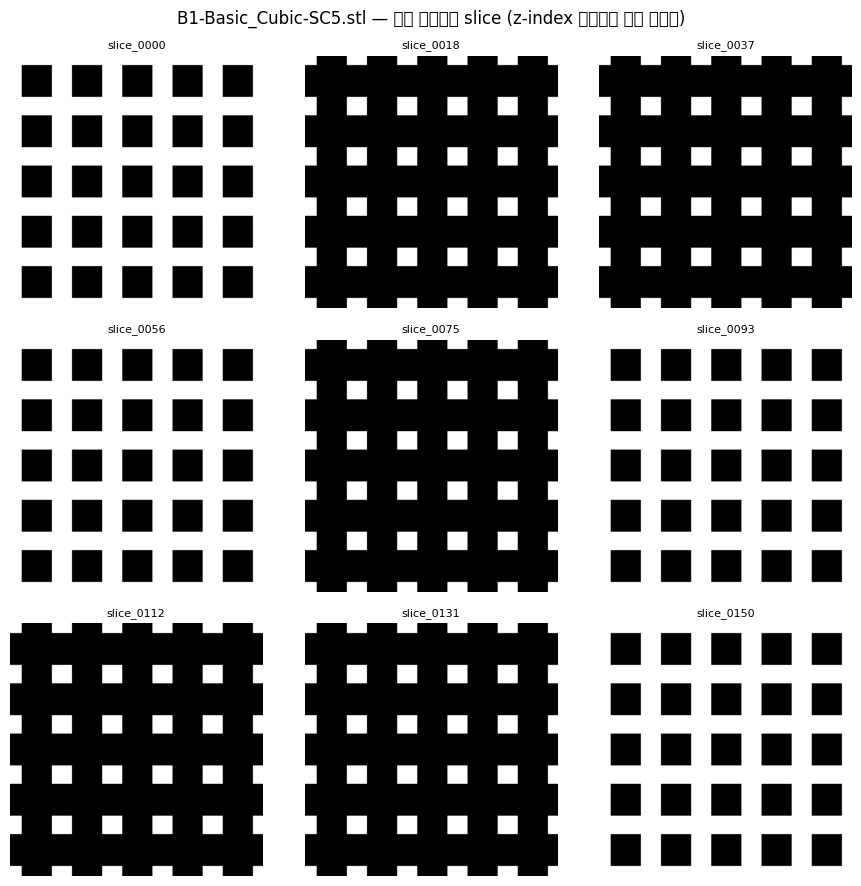

In [5]:
FILE_INDEX = 0  # <- 확인하고 싶은 파일 번호로 변경

sel = results[FILE_INDEX]
print('선택한 파일:', sel['file'], '| 상태:', sel['status'])
workdir = Path(sel['workdir'])

if sel['status'] != 'OK':
    print('이 파일은 처리에 실패했습니다. logs/error.txt를 확인하세요:', workdir / 'logs' / 'error.txt')
    print((workdir / 'logs' / 'error.txt').read_text(encoding='utf-8')[-2000:])
else:
    slice_dir = workdir / 'images' / 'raw_slices'
    slice_files = sorted(slice_dir.glob('*.png'))
    print(f'저장된 slice 이미지 {len(slice_files)}장 (경로: {slice_dir})')
    n_show = min(9, len(slice_files))
    pick = np.linspace(0, len(slice_files) - 1, n_show).astype(int) if slice_files else []
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for ax, idx in zip(axes.ravel(), pick):
        img = Image.open(slice_files[idx])
        ax.imshow(img, cmap='gray'); ax.set_title(slice_files[idx].stem, fontsize=8); ax.axis('off')
    for ax in axes.ravel()[len(pick):]:
        ax.axis('off')
    plt.suptitle(f'{sel["file"]} — 실제 이진화된 slice (z-index 순서대로 균등 샘플링)')
    plt.tight_layout(); plt.show()

## 5. 3-Layer A/B/C 중첩(TSPE) 이미지로 확인하기

- **Hard-TSPE** (`images/triplets/*_ABC.png`): A(3-layer 모두 겹침)=255(밝음), B(N&N+1만)=170, C(N+1&N+2만)=85(어두움), 배경=0.
- **Soft-TSPE** (`images/soft_triplets/*_ABC_rgb.png`): grayscale 기반 fuzzy A/B/C를 RGB로 합성한 버전 (v4.1, partial-volume 정보 보존).

hard-TSPE ABC 이미지 149장, soft-TSPE RGB 이미지 149장


C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\2664221398.py:21: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\2664221398.py:21: UserWarning: Glyph 52393 (\N{HANGUL SYLLABLE CEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\2664221398.py:21: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\2664221398.py:21: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\2664221398.py:21: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\2664221398.py:21: UserWarning: Gly

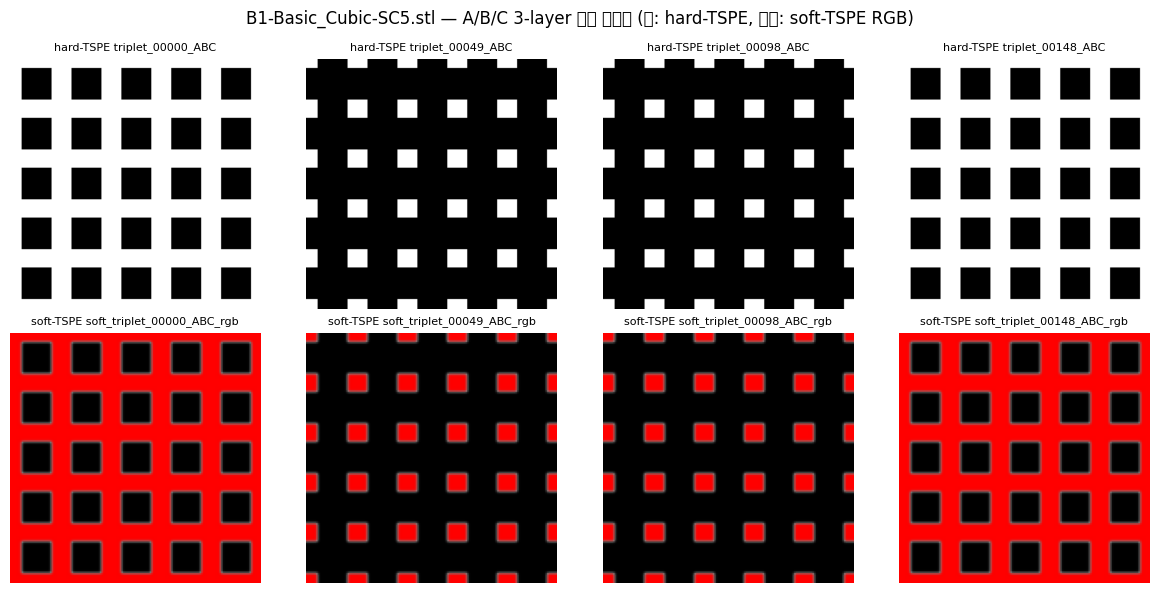

In [6]:
triplet_dir = workdir / 'images' / 'triplets'
soft_triplet_dir = workdir / 'images' / 'soft_triplets'

triplet_files = sorted(triplet_dir.glob('*_ABC.png')) if triplet_dir.exists() else []
soft_files = sorted(soft_triplet_dir.glob('*_ABC_rgb.png')) if soft_triplet_dir.exists() else []
print(f'hard-TSPE ABC 이미지 {len(triplet_files)}장, soft-TSPE RGB 이미지 {len(soft_files)}장')

n_show = min(4, len(triplet_files))
if n_show:
    pick = np.linspace(0, len(triplet_files) - 1, n_show).astype(int)
    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    for j, idx in enumerate(pick):
        axes[0, j].imshow(Image.open(triplet_files[idx]), cmap='gray')
        axes[0, j].set_title(f'hard-TSPE {triplet_files[idx].stem}', fontsize=8); axes[0, j].axis('off')
        if idx < len(soft_files):
            axes[1, j].imshow(Image.open(soft_files[idx]))
            axes[1, j].set_title(f'soft-TSPE {soft_files[idx].stem}', fontsize=8); axes[1, j].axis('off')
        else:
            axes[1, j].axis('off')
    plt.suptitle(f'{sel["file"]} — A/B/C 3-layer 중첩 이미지 (위: hard-TSPE, 아래: soft-TSPE RGB)')
    plt.tight_layout(); plt.show()
else:
    print('저장된 중첩 이미지가 없습니다 (SAVE_TRIPLET_IMAGES 설정 또는 파이프라인 실패 여부를 확인하세요).')

## 6. 이 파일의 구조인자 추출 결과

`features/descriptors_ALL.csv`에 exhaustive 모드의 전체 descriptor(현재 v4.1 기준 약 8,000여 개)가 저장되어 있습니다. 아래는 그중 핵심 지표 요약과, v4.1 슬라이싱 진단(mesh repair / voxelization backend / odd-scanline QA)입니다.

In [7]:
csv_path = workdir / 'features' / 'descriptors_ALL.csv'
if csv_path.exists():
    full_df = pd.read_csv(csv_path)
    print(f'전체 descriptor 수: {full_df.shape[1] - 1}개 (sample_id 제외), 파일: {csv_path}')
    display(full_df.head())
else:
    full_df = None
    print('descriptors_ALL.csv를 찾지 못했습니다.')

print('\n--- 핵심 구조인자 요약 ---')
summary = drv.summarize_key_descriptors(workdir)
for k, v in summary.items():
    print(f'{k}: {v}')

meta_path = workdir / 'checkpoints' / '01_input_meta.json'
if meta_path.exists():
    meta = json.loads(meta_path.read_text(encoding='utf-8'))
    print('\n--- v4.1 슬라이싱 진단 (STL/STEP 입력일 때) ---')
    print('voxelization_backend:', meta.get('voxelization_backend'))
    print('mesh_repair:', json.dumps(meta.get('mesh_repair', {}), indent=2, ensure_ascii=False))
    qa = meta.get('slicing_qa', {})
    if qa:
        print(f"odd-parity scanline row가 남은 slice: {qa.get('n_odd_slices')} / {qa.get('n_slices')}")
        if qa.get('n_odd_slices'):
            print('  -> 0보다 크면 README_KO.md의 v4.1 절 참고 (backend=\'trimesh_fill\' 강제 권장)')

전체 descriptor 수: 8106개 (sample_id 제외), 파일: C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Test_20260902_021604\B1-Basic_Cubic-SC5\features\descriptors_ALL.csv


,sample_id,slice_area_fraction_n,slice_area_fraction_mean,slice_area_fraction_std,slice_area_fraction_min,slice_area_fraction_q01,slice_area_fraction_q05,slice_area_fraction_q10,slice_area_fraction_q25,slice_area_fraction_median,...,ct_recon_skeleton_sampled_solid_thickness_mm_q95,ct_recon_skeleton_sampled_solid_thickness_mm_q99,ct_recon_skeleton_sampled_solid_thickness_mm_max,ct_recon_skeleton_sampled_solid_thickness_mm_iqr,ct_recon_skeleton_sampled_solid_thickness_mm_range,ct_recon_skeleton_sampled_solid_thickness_mm_cv,ct_recon_skeleton_sampled_solid_thickness_mm_skew,ct_recon_skeleton_sampled_solid_thickness_mm_kurtosis,ct_recon_skeleton_sampled_solid_thickness_mm_rms,ct_recon_skeleton_sampled_solid_thickness_mm_mad
0,B1-Basic_Cubic-SC5,151,0.341786,0.233176,0.149818,0.149818,0.149818,0.149818,0.149818,0.149818,...,2.884441,3.1241,3.394113,0.8,2.194113,0.289457,0.153607,-1.057247,2.039092,0.4



--- 핵심 구조인자 요약 ---
relative_density: 0.3417855787084974
surface_area_mm2: 12339.900916620469
curvature_area_weighted_mean_H_per_mm: 0.2236049060913547
curvature_area_weighted_mean_K_per_mm2: -0.2604505772602668
tortuosity_solid_mean_xyz: 1.036027538413926
tortuosity_void_mean_xyz: 1.0000000000000004
strut_network_mean_coordination_number_Z: 4.055091819699499
strut_count: 2429
_descriptor_count: 8106
_voxelization_backend: trimesh_fill
_mesh_repair: {'watertight_before': True, 'weld_tolerance_mm': 0.0002, 'vertex_weld_applied': True, 'watertight_after': True, 'n_vertices': 1608, 'n_faces': 4512, 'repaired': True}
_slicing_qa_n_odd_slices: None
_slicing_qa_n_slices: None

--- v4.1 슬라이싱 진단 (STL/STEP 입력일 때) ---
voxelization_backend: trimesh_fill
mesh_repair: {
  "watertight_before": true,
  "weld_tolerance_mm": 0.0002,
  "vertex_weld_applied": true,
  "watertight_after": true,
  "n_vertices": 1608,
  "n_faces": 4512,
  "repaired": true
}
odd-parity scanline row가 남은 slice: None / None


## 7. 핵심 구조인자 빠른 시각화 (선택)

density/thickness/curvature/tortuosity처럼 스케일이 크게 다른 값들을 한 번에 비교하기 위해 0~1로 정규화해서 막대그래프로 봅니다 (정확한 값은 위 표 또는 6번 셀의 출력을 참고하세요 — 이 그래프는 상대적 크기 비교용입니다).

C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1599487037.py:9: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1599487037.py:9: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1599487037.py:9: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1599487037.py:9: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1599487037.py:9: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\김민겸\AppData\Local\Temp\ipykernel_25424\1599487037.py:9: UserWarning: Gly

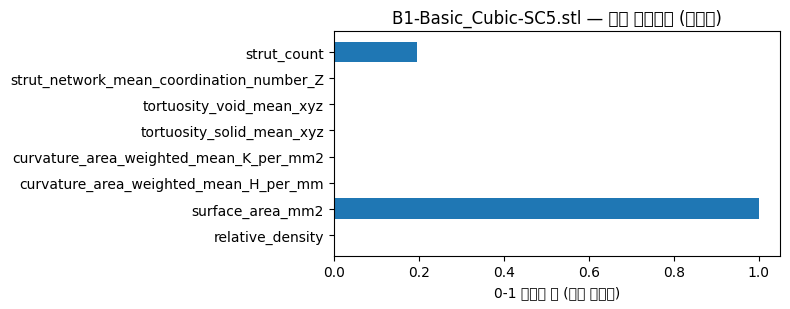

In [8]:
plot_keys = [k for k in summary if not k.startswith('_') and isinstance(summary[k], (int, float))]
if plot_keys:
    vals = np.array([summary[k] for k in plot_keys], dtype=float)
    norm = (vals - np.nanmin(vals)) / (np.nanmax(vals) - np.nanmin(vals) + 1e-12)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(plot_keys))))
    ax.barh(plot_keys, norm)
    ax.set_xlabel('0-1 정규화 값 (상대 비교용)')
    ax.set_title(f'{sel["file"]} — 핵심 구조인자 (정규화)')
    plt.tight_layout(); plt.show()
else:
    print('표시할 수치형 핵심 구조인자가 없습니다.')

---
### 참고
- 전체 8,000여 개 exhaustive descriptor는 각 파일의 `features/descriptors_ALL.csv`에서 직접 확인하세요.
- 여러 파일을 한 번에 열어 상호 비교하려면 `OUTPUT_DIR / 'MASTER_descriptors_ALL.csv'` 대신, 이번 실행 결과는 파일별 폴더에 나뉘어 있으므로 아래 셀로 통합할 수 있습니다.
- 이 노트북은 테스트/시각 확인 전용입니다. 실제 연구/분석에 쓸 최종 결과는 `Architected_Material_Descriptor_v3.ipynb`를 직접 실행하거나 `run_stl_batch_descriptor_extraction.py`(Result_ 폴더)를 사용하세요.

In [9]:
frames = []
for r in results:
    p = Path(r['workdir']) / 'features' / 'descriptors_ALL.csv'
    if p.exists():
        df = pd.read_csv(p)
        df.insert(0, 'source_file', r['file'])
        frames.append(df)
if frames:
    master = pd.concat(frames, ignore_index=True, sort=False)
    master_path = OUTPUT_DIR / 'MASTER_descriptors_ALL.csv'
    master.to_csv(master_path, index=False)
    print(f'통합 결과 저장: {master_path}  (shape={master.shape})')
else:
    print('성공한 파일이 없어 통합 결과를 만들지 못했습니다.')

통합 결과 저장: C:\Users\김민겸\Desktop\Metal metamaterial\Descriptor extraction\Test_20260902_021604\MASTER_descriptors_ALL.csv  (shape=(34, 8113))
